# U.S. Medical Insurance Costs--Step6 RF benchmark to improve predictability

In [16]:
# The Random Forest model achieved higher predictive accuracy compared to the linear regression models, suggesting that insurance costs contain important nonlinear relationships and interaction effects.
# Feature importance analysis confirmed that smoking status was the dominant predictor of medical insurance charges, followed by age and BMI.
# Compared with OLS regression, Random Forest better captured high-cost patients and reduced prediction errors.
import pandas as pd

In [17]:
# Read the CSV file
ins_cleaned_df = pd.read_csv("/Users/shenkong/Desktop/Projects/pj02_US_Medical_Insurance_Costs/data/ins_cleaned.csv")
ins_cleaned_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1332,50,male,30.970,3,no,northwest,10600.54830
1333,18,female,31.920,0,no,northeast,2205.98080
1334,18,female,36.850,0,no,southeast,1629.83350
1335,21,female,25.800,0,no,southwest,2007.94500


In [18]:
# One-hot encoding:
df_encoded = pd.get_dummies(ins_cleaned_df, drop_first=True)

# Define X and y:
X = df_encoded[[
    "age",
    "bmi",
    "children",
    "smoker_yes"
]].astype(float)

y = df_encoded["charges"]

In [19]:
# Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,  # Split the dataset into 80% training and 20% testing data
    random_state=42
)

In [20]:
# Build Random Forest Regressor:
from xml.parsers.expat import model

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,  # Use 200 trees to improve model stability and predictive performance
    random_state=42,  # Fix the random seed to ensure reproducible results
)

rf_model.fit(X_train, y_train)  # Model Configuration

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [21]:
# Make prediction:
y_pred_rf = rf_model.predict(X_test)

In [22]:
# Evaluate model-- Show one of the results (Performance Metrics):
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
)

import numpy as np
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

print(f"R-squared: {r2_rf}")
print(f"MAE: {mae_rf}")
print(f"RMSE: {rmse_rf}")

R-squared: 0.8725206077315607
MAE: 2703.8187943134326
RMSE: 4839.949521389635


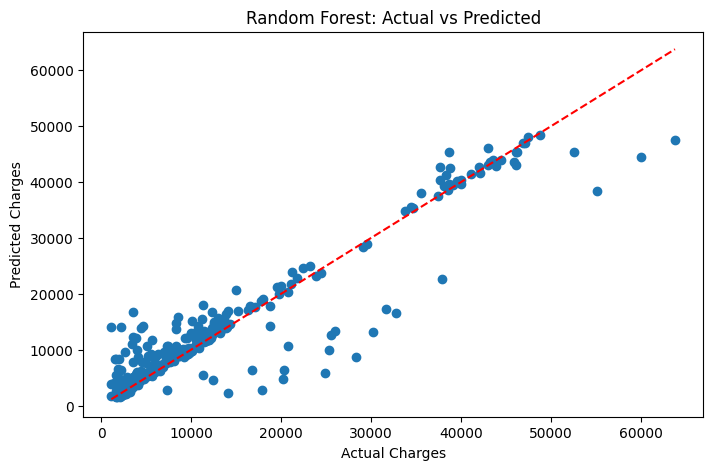

<Figure size 640x480 with 0 Axes>

In [23]:
# Actual vs Predicted Plot:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred_rf,
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Random Forest: Actual vs Predicted")

plt.savefig("/Users/shenkong/Desktop/Projects/pj02_US_Medical_Insurance_Costs/images/RF_Actual_vs_Predicted.png")
plt.show()
plt.clf()

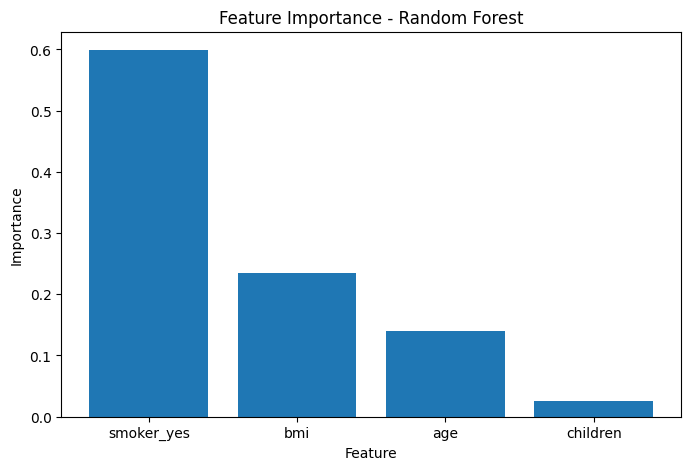

<Figure size 640x480 with 0 Axes>

In [24]:
# Show one of the results-- Feature Importance:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = (
    importance_df.sort_values(
        by="Importance",
        ascending=False
    )
)

# Visualize Feature Importance
plt.figure(figsize=(8, 5))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance - Random Forest")

plt.savefig("/Users/shenkong/Desktop/Projects/pj02_US_Medical_Insurance_Costs/images/RF_Feature_Importance.png")
plt.show()
plt.clf()